# Data Quality & EDA - IT Asset Management
This notebook is used for Exploratory Data Analysis (EDA) and verifying intentionally planted Data Traps.
💡 Instruction: You can run each code cell directly in VS Code by clicking "Run Cell" (Jupyter extension required).
This is more convenient than a pure .ipynb file for Git version control.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sqlalchemy import create_engine
import os
import sys
from dotenv import load_dotenv

# Set UTF-8 encoding
if hasattr(sys.stdout, 'reconfigure'):
    sys.stdout.reconfigure(encoding='utf-8')

# Display configuration
pd.set_option('display.max_columns', None)
sns.set_theme(style="whitegrid")

# Helper function to handle display/print (Notebook vs CLI)
def smart_display(df, title=None):
    if title: print(f"\n--- {title} ---")
    if 'IPYTHON_SHELL' in globals() or 'get_ipython' in globals():
        from IPython.display import display
        display(df)
    else:
        print(df.to_string())

## 1. Database Connection
Use SQLAlchemy to read data from Postgres. If DB is unavailable, fallback to raw CSVs.

In [2]:
# Load environment variables
load_dotenv('../.env')

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASS = os.getenv("DB_PASS")

# Create connection
engine = create_engine(f'postgresql://{DB_USER}:{DB_PASS}@{DB_HOST}:{DB_PORT}/{DB_NAME}')

try:
    df_assets = pd.read_sql("SELECT * FROM trf_assets", engine)
    df_enroll = pd.read_sql("SELECT * FROM stg_enrollment", engine)
    df_employees = pd.read_sql("SELECT * FROM trf_employees", engine)
    print("✅ Successfully loaded data from Database!")
except Exception as e:
    print(f"⚠️ DB connection issue (Fallback to CSV): {e}")
    raw_dir = os.path.join('..', 'data', 'raw')
    
    def load_raw_csv(filename_patterns):
        for pattern in filename_patterns:
            path = os.path.join(raw_dir, pattern)
            if os.path.exists(path):
                return pd.read_csv(path)
        raise FileNotFoundError(f"Could not find any of {filename_patterns} in {raw_dir}")

    df_assets = load_raw_csv(['extract_assets.csv', 'master_assets.csv'])
    df_enroll = load_raw_csv(['extract_enrollment.csv', 'master_enrollment.csv'])
    df_employees = load_raw_csv(['extract_employees.csv', 'master_employees.csv'])
    
    df_assets.columns = df_assets.columns.str.lower()
    df_enroll.columns = df_enroll.columns.str.lower()
    df_employees.columns = df_employees.columns.str.lower()
    print("✅ Successfully loaded data from local CSV files!")

⚠️ DB connection issue (Fallback to CSV): (psycopg2.OperationalError) connection to server at "localhost" (::1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?
connection to server at "localhost" (127.0.0.1), port 5432 failed: Connection refused (0x0000274D/10061)
	Is the server running on that host and accepting TCP/IP connections?

(Background on this error at: https://sqlalche.me/e/20/e3q8)
✅ Successfully loaded data from local CSV files!


## 2. Data Profiling
High-level overview to understand the big picture.

--- DATA OVERVIEW ---
Device count (Assets): 50000
MDM records count (Enrollment): 14577
Employee count: 200

--- MISSING VALUES ---


processor_model         7547
processor_cores         7547
ram_capacity_gb         7547
storage_capacity_tb     7547
gpu_model               7547
encryption_type        12269
cve_list                6774
assigned_to_id         30024
dtype: int64

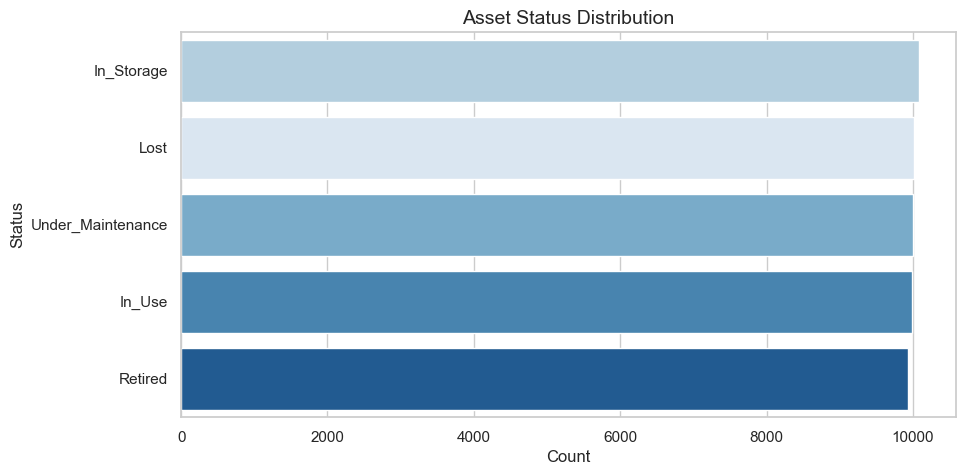

In [3]:
print("--- DATA OVERVIEW ---")
print(f"Device count (Assets): {len(df_assets)}")
print(f"MDM records count (Enrollment): {len(df_enroll)}")
print(f"Employee count: {len(df_employees)}")

print("\n--- MISSING VALUES ---")
smart_display(df_assets.isnull().sum()[df_assets.isnull().sum() > 0])

# Visualize device status distribution
plt.figure(figsize=(10, 5))
sns.countplot(
    data=df_assets, 
    y='asset_status', 
    order=df_assets['asset_status'].value_counts().index, 
    hue='asset_status', 
    palette='Blues_r', 
    legend=False
)
plt.title("Asset Status Distribution", fontsize=14)
plt.xlabel("Count")
plt.ylabel("Status")
plt.show()

## 3. Outlier Detection (Histogram & Boxplot)

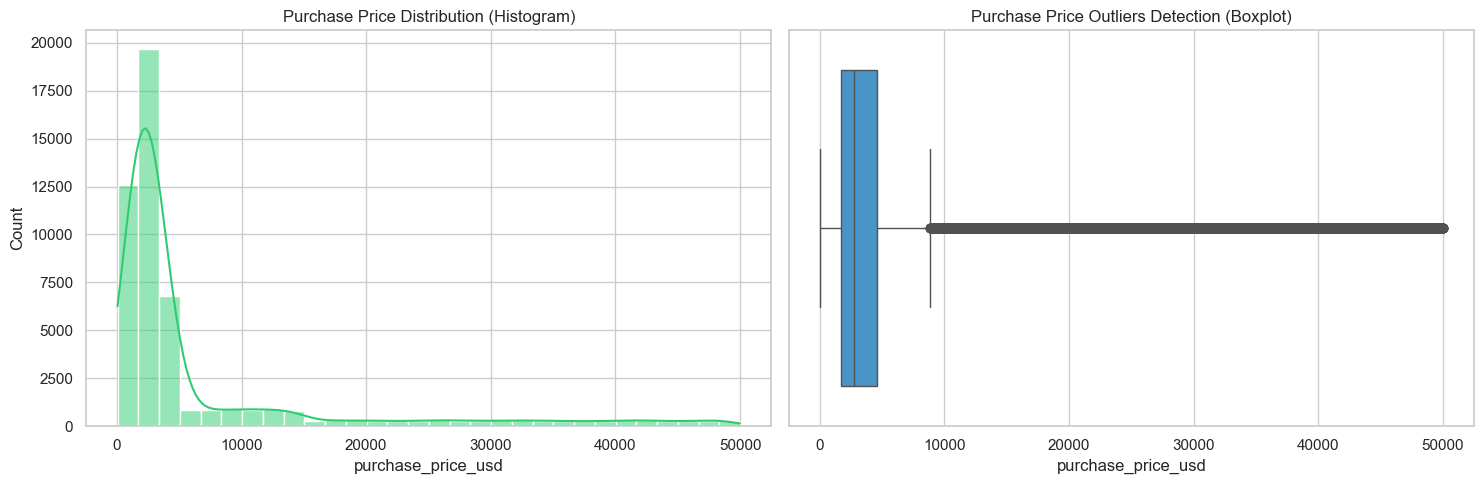

Top 5 most expensive devices (Potential Outliers):


,serial_number,device_category,purchase_price_usd,asset_status
23560,SN-C23D2E655B2DF31B,Server,49998.36,In_Use
3524,SN-8391BDD4EE95B97D,Server,49988.93,Retired
8898,SN-5685DC64E045DD07,Server,49987.34,Retired
9588,SN-729BAE6D07B0102A,Server,49976.04,In_Use
10838,SN-280CC6A83AC313E6,Server,49972.84,In_Use


In [4]:
plt.figure(figsize=(15, 5))

# 3.1 Histogram
plt.subplot(1, 2, 1)
sns.histplot(df_assets['purchase_price_usd'], bins=30, kde=True, color='#2ecc71')
plt.title("Purchase Price Distribution (Histogram)")

# 3.2 Boxplot
plt.subplot(1, 2, 2)
sns.boxplot(x=df_assets['purchase_price_usd'], color='#3498db')
plt.title("Purchase Price Outliers Detection (Boxplot)")

plt.tight_layout()
plt.show()

# Display outlier devices
print("Top 5 most expensive devices (Potential Outliers):")
smart_display(df_assets.nlargest(5, 'purchase_price_usd')[['serial_number', 'device_category', 'purchase_price_usd', 'asset_status']])

## 4. Business Data Traps Analysis

In [5]:
# Merge data for reconciliation
df_audit = pd.merge(df_assets, df_enroll, on='serial_number', how='outer', indicator=True)

assigned_col = 'assigned_to_id' if 'assigned_to_id' in df_audit.columns else 'Assigned_To_ID'
primary_user_col = 'primary_user' if 'primary_user' in df_audit.columns else 'Primary_User'
emp_id_col = 'employee_id' if 'employee_id' in df_employees.columns else 'Employee_ID'

df_audit = pd.merge(df_audit, df_employees, left_on=assigned_col, right_on=emp_id_col, how='left')
df_audit['_merge_type'] = df_audit['_merge'].map({'left_only': 'Asset Only', 'right_only': 'Enrollment Only', 'both': 'Both'})

# 4.1 Missing Enrollment
missing_enrollment = df_audit[
    (df_audit['asset_status'].isin(['In_Use', 'Under_Maintenance'])) & 
    (df_audit['_merge_type'] == 'Asset Only')
]
print(f"🚨 Detected {len(missing_enrollment)} Missing Enrollment devices")

# 4.2 Ghost Device
ghost_devices = df_audit[
    (df_audit['asset_status'].isin(['Retired', 'In_Storage', 'Lost'])) & 
    (df_audit['_merge_type'] == 'Both')
]
print(f"👻 Detected {len(ghost_devices)} Ghost Devices")

# 4.3 Mismatch User
df_both = df_audit[df_audit['_merge_type'] == 'Both'].copy()
mismatch_user = df_both[df_both[assigned_col] != df_both[primary_user_col]]
valid_employees = df_employees[emp_id_col].tolist()
virtual_employees = df_both[~df_both[primary_user_col].isin(valid_employees)]

print(f"⚠️ Detected {len(mismatch_user)} cases of Mismatch User")
print(f"🕵️ Detected {len(virtual_employees)} cases of Virtual Employee")

🚨 Detected 6451 Missing Enrollment devices
👻 Detected 1052 Ghost Devices
⚠️ Detected 2673 cases of Mismatch User
🕵️ Detected 1216 cases of Virtual Employee


### 4.4. Summary of Data Quality Issues

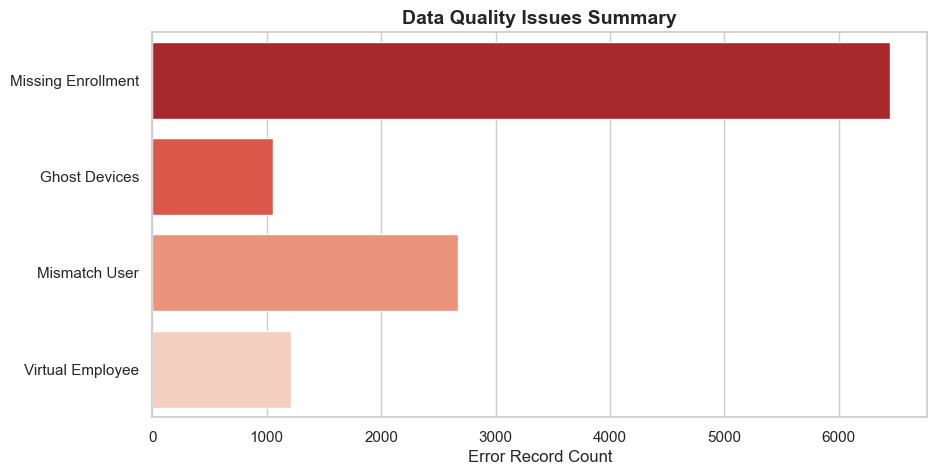

In [6]:
trap_counts = {
    "Missing Enrollment": len(missing_enrollment),
    "Ghost Devices": len(ghost_devices),
    "Mismatch User": len(mismatch_user),
    "Virtual Employee": len(virtual_employees)
}

plt.figure(figsize=(10, 5))
sns.barplot(x=list(trap_counts.values()), y=list(trap_counts.keys()), hue=list(trap_counts.keys()), palette="Reds_r", legend=False)
plt.title("Data Quality Issues Summary", fontsize=14, fontweight='bold')
plt.xlabel("Error Record Count")
plt.show()

## 5. Advanced Analysis: Department Breakdown


--- Departmental Investment Summary ---


,Asset Count,Total Investment (USD)
department,,
Finance,3715,24475539.10
Operations,3487,22909337.50
IT,3342,21828730.41
Academic,3279,22458190.41
HR,3110,20394346.24
Sales,3043,20505638.13


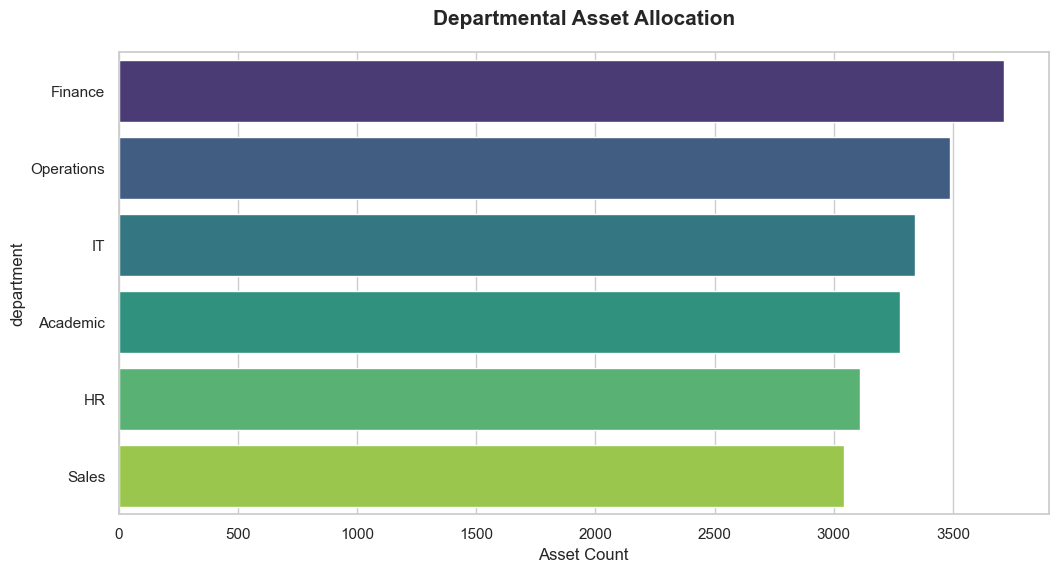

In [7]:
dept_analysis = df_audit.groupby('department').agg({
    'serial_number': 'count',
    'purchase_price_usd': 'sum'
}).rename(columns={
    'serial_number': 'Asset Count',
    'purchase_price_usd': 'Total Investment (USD)'
}).sort_values('Asset Count', ascending=False)

smart_display(dept_analysis, "Departmental Investment Summary")

plt.figure(figsize=(12, 6))
sns.barplot(
    data=dept_analysis.reset_index(), 
    x='Asset Count', 
    y='department', 
    hue='department', 
    palette='viridis', 
    legend=False
)
plt.title("Departmental Asset Allocation", fontsize=15, fontweight='bold', pad=20)
plt.show()

In [8]:
# Final Cleanup
engine.dispose()